# makeshift — CPMG relaxation dispersion

End-to-end: from a set of CPMG planes to per-residue R₂,eff and a classification of which residues show conformational exchange (Rex).

In [ ]:
import matplotlib.pyplot as plt
from makeshift.utils.datasets import fetch
from makeshift.relaxation import CPMGExperiment

## 0. Get the example dataset

Downloads to `~/.makeshift/datasets/` and returns the data directory. The example config (`examples/SHP2_NSH2_CPMG.yaml`) already points at this location.

In [2]:
data_dir = fetch('SHP2_NSH2_CPMG')
data_dir

PosixPath('/home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG')

## 1. Run the pipeline

`from_config` loads the config and reads the planes; `.run` picks peaks, maps the reference assignments, fits lineshapes, computes R₂,eff, classifies, and writes a results CSV. Pass `make_plots=True` for diagnostic PDFs. (~2 min on an M2.)

In [3]:
exp = CPMGExperiment.from_config('../examples/SHP2_NSH2_CPMG.yaml').run('out/')
exp.classifications['label'].value_counts()

== Loading config and planes ==
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_50_6_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_50_14_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_100_9_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_150_2_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_200_11_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_250_7_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_350_3_SH2-WB_N15-CPMG.ucsf
read data from /home/users/gelnesr/.makeshift/datasets/SHP2_NSH2_CPMG/SHP2_NSH2_CPMG/nuCPMG_450_12_SH2-WB_N15-CPMG.ucsf
read data from 

label
flat           66
Rex            22
elevated_R2     5
Name: count, dtype: int64

Results are stored on the experiment: `exp.ref_df` (picked + assigned peaks), `exp.all_r2eff` (per-peak dispersion), `exp.classifications` (labels + Rex).

In [4]:
exp.classifications.head()

,ref_index,R2first,R2last,std_first,std_last,std_total,assn_label,seqpos,R2_hydro,scaled_R2_pred,rigid_rmse,Rex_val,Rex_err,Rex,label,elevated_R2
0,83,9.609384,8.068411,0.514937,1.193138,2.028458,M1,1,9.859577,10.678516,0.930509,1.540974,1.708074,False,flat,False
1,46,9.216547,7.630439,0.710092,1.159701,2.548855,T2,2,9.929186,10.753907,0.930509,1.586108,1.869793,False,flat,False
2,82,11.092871,10.521920,0.502809,0.808635,1.330800,R5,5,9.966527,10.794349,0.930509,0.570951,1.311444,False,flat,False
3,52,12.615609,11.784025,0.226213,0.394393,1.232711,W6,6,9.932954,10.757987,0.930509,0.831584,0.620606,False,flat,False
4,13,12.195103,11.466905,0.192620,0.518516,1.004934,F7,7,9.999164,10.829697,0.930509,0.728198,0.711135,False,flat,False


Text(0, 0.5, 'Rex (s⁻¹)')

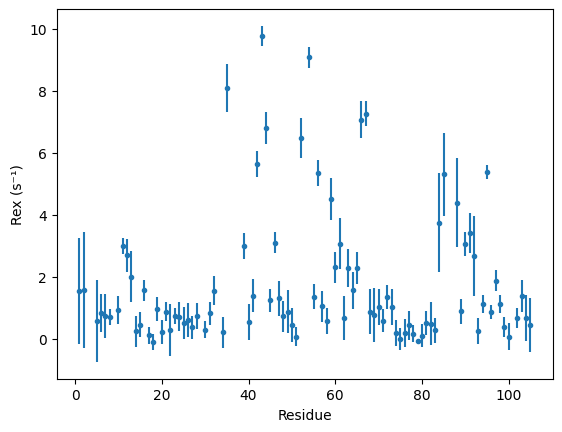

In [5]:
# Estimated Rex per residue
c = exp.classifications
plt.errorbar(c['seqpos'], c['Rex_val'], yerr=c['Rex_err'], fmt='.')
plt.xlabel('Residue'); 
plt.ylabel('Rex (s⁻¹)')

## 2. Visualize

The relaxation plotting helpers take the results directly. Orange = conventional Rex, green = unsuppressed (elevated) R₂.

(<Figure size 730x150 with 1 Axes>,
 <Axes: xlabel='Residue', ylabel='$R_2$ (s$^{-1}$)'>)

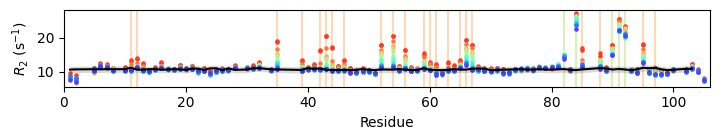

In [6]:
from makeshift.relaxation.plotting import plot_waterfall, plot_r2eff_grid
plot_waterfall(exp.all_r2eff, exp.classifications, exp.ref_df)

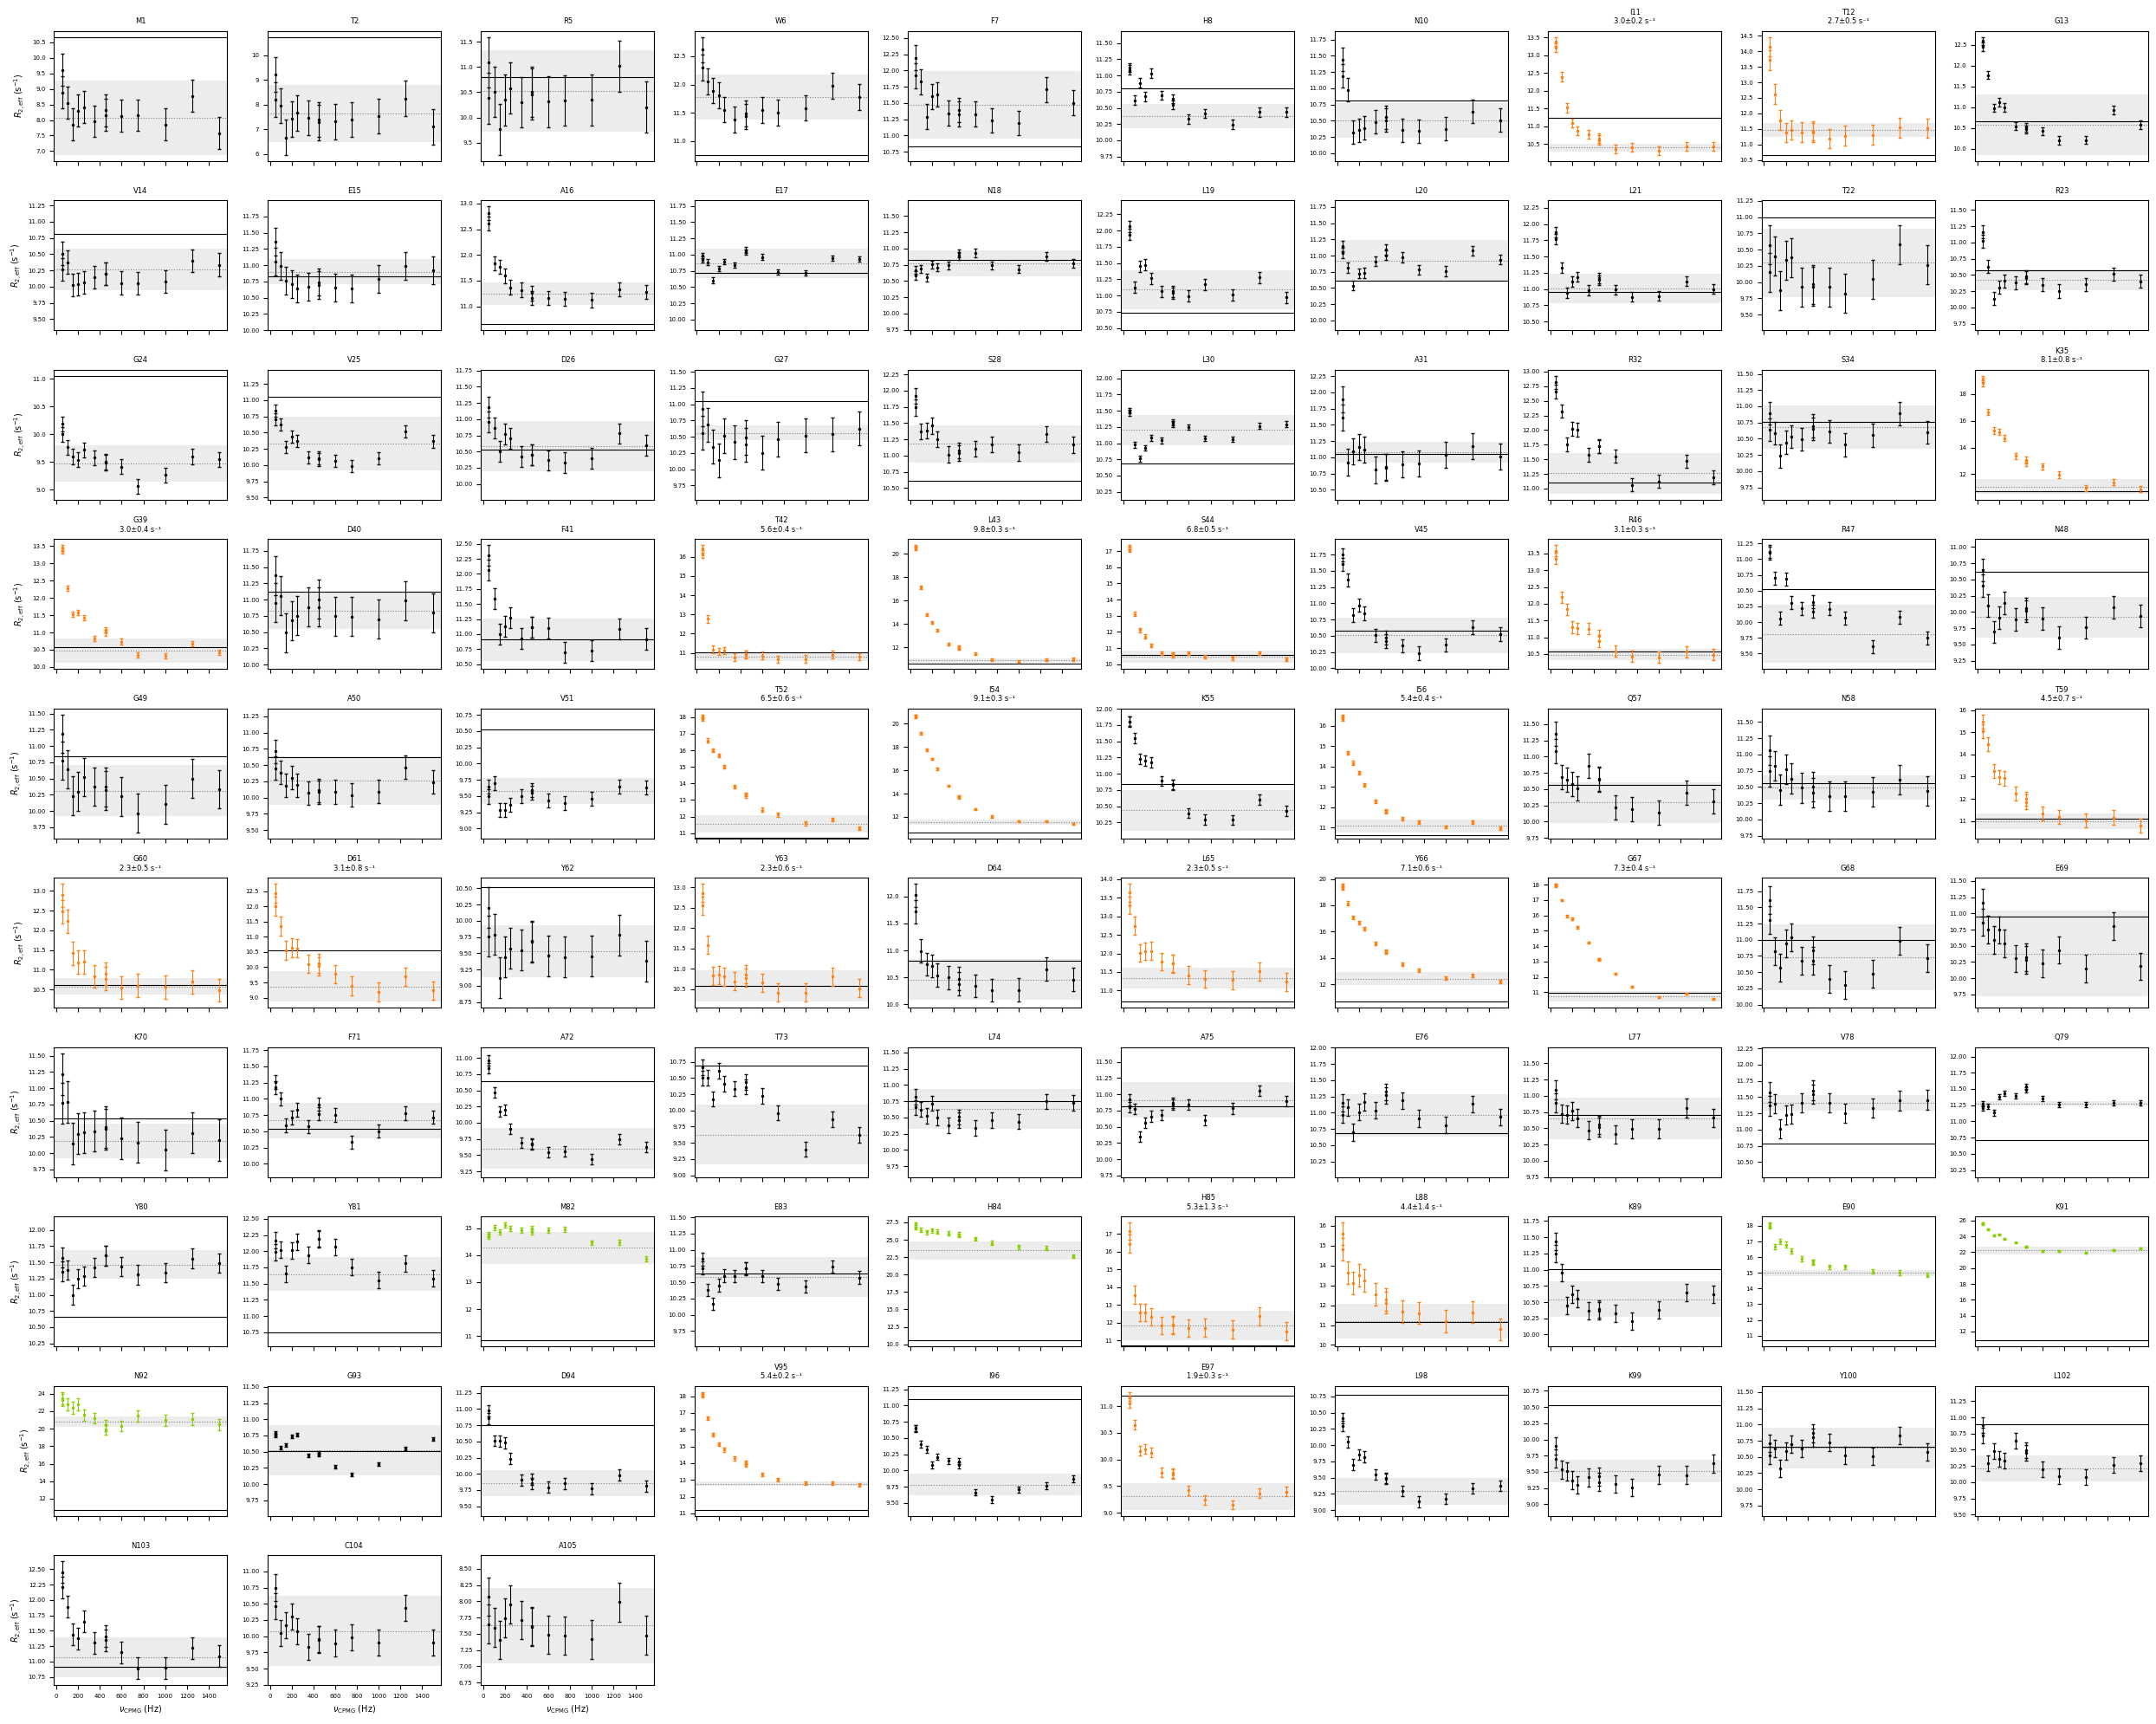

In [10]:
fig, axes = plot_r2eff_grid(exp.all_r2eff, exp.classifications, exp.ref_df)

## 3. Under the hood (optional)

`run()` is a thin wrapper over the stage functions. Call them directly to customize — e.g. tune the peak-mapping tolerance or supply your own `PeakList`.

In [8]:
from makeshift import PeakList
from makeshift.spectra import Spectrum, map_peaklists
from makeshift.spectra.plotting import plot_spectrum, plot_peaklist
from makeshift.relaxation import load_config

config = load_config('../examples/SHP2_NSH2_CPMG.yaml')
hsqc = Spectrum.from_ucsf(config['reference'])
peaks = hsqc.pick_peaks(baseline=config['baseline_ref_plane'])
peaks.head()

,N_axis,H_axis,cid,N_lw,H_lw,est_vol,N_ppm,H_ppm
0,13.0,310.0,1,2.544941,6.010375,6.122695e+08,131.356559,10.581259
1,18.0,451.0,2,2.753780,4.941695,5.416286e+08,130.714273,9.434052
2,19.0,396.0,3,2.574616,5.944042,2.215684e+08,130.585816,9.881544
3,27.0,537.0,4,2.817441,6.790002,5.228370e+08,129.558160,8.734337
4,28.0,560.0,5,2.839071,4.209592,7.075960e+08,129.429703,8.547204


Map a reference (assigned) peaklist onto the picked peaks. `map_peaklists` grid-searches the best translation, then does Hungarian matching. The reference can be a `PeakList`, a DataFrame, a BMRB id, or a CSV path — here the config gives a BMRB id.

  Running grid search for best (Δ¹H, Δ¹⁵N) offset...
  Best offset: Δ¹H = +0.080, Δ¹⁵N = +0.000 ppm (RMSE = 0.307, 96/100 peaks within tolerance)
  3 conflict(s) flagged for manual inspection:
    spectrum peak  99: assigned H85,  competing R4
    spectrum peak  38: assigned E17,  competing F29
    spectrum peak  99: assigned H85,  competing N37
  93/100 peaks in right peaklist assigned  |  2 flagged for inspection


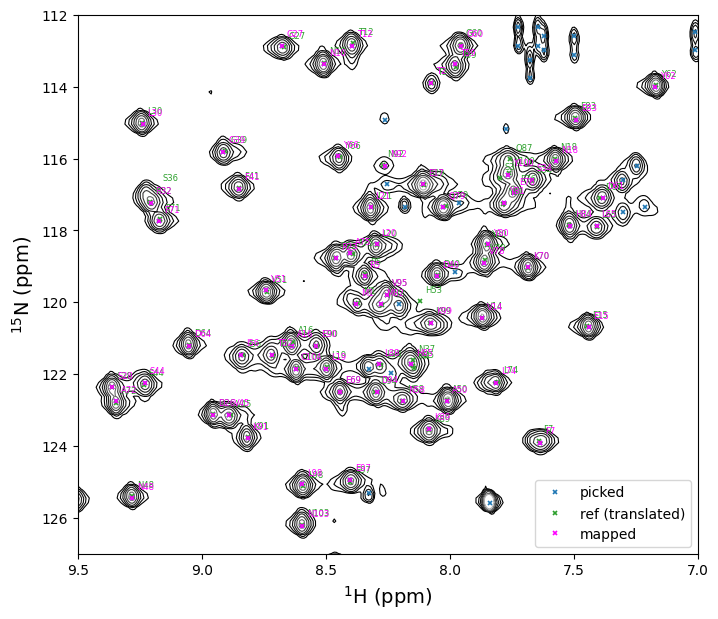

In [ ]:
ref = PeakList.from_bmrb(config['peaklist']).data
assigned, ref_translated = map_peaklists(peaks, ref, tol=config['peak_mapping_tol'])

fig, ax = plot_spectrum(hsqc, baseline=config['baseline_ref_plane'],
                        xlim=(9.5, 7), ylim=(127, 112), cmap='Greys_r')
plot_peaklist(ax, peaks, text=None, color='tab:blue', label='picked')
plot_peaklist(ax, ref_translated, text='assn_label', color='tab:green', label='ref (translated)')
plot_peaklist(ax, assigned, text='assn_label', color='magenta', label='mapped')
plt.legend(loc='lower right')